# データの読み込み

## 定性確認

In [3]:
import struct
import numpy as np
import torch


def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # ヘッダ部分のメタデータを読み込む（マジックナンバー、画像数、行数、列数）
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        # 画像データの読み込み
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

In [4]:
BASE = '/home/hashikami/datadrive/MorphoMNIST'
train_images_file = BASE + '/train-images-idx3-ubyte'
train_labels_file = BASE + '/train-labels-idx1-ubyte'

train_images_np = load_mnist_images(train_images_file)
train_labels_np = load_mnist_labels(train_labels_file)

# 画像データを[0, 1]にスケーリング
train_images_tensor = torch.tensor(train_images_np, dtype=torch.float32) / 255.0
train_images_tensor = train_images_tensor.unsqueeze(1)
train_labels_tensor = torch.tensor(train_labels_np, dtype=torch.long)


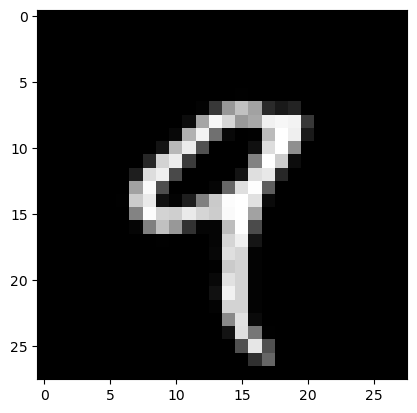

In [5]:
# MNISTデータの可視化

import matplotlib.pyplot as plt

plt.imshow(train_images_tensor[4].permute(1, 2, 0), cmap='gray')

In [6]:
# ラベルの値
for i in range(10):
    print('value of label=', train_labels_tensor[i])

value of label= tensor(5)
value of label= tensor(0)
value of label= tensor(4)
value of label= tensor(1)
value of label= tensor(9)
value of label= tensor(2)
value of label= tensor(1)
value of label= tensor(3)
value of label= tensor(1)
value of label= tensor(4)


In [7]:
# 形態情報

import pandas as pd

train_shape_df = pd.read_csv(BASE + '/train-morpho.csv')
train_shape_df.head()

,index,thickness,intensity
0,0,2.398951,162.27393
1,1,2.789006,171.67532
2,2,2.655154,206.75359
3,3,2.852611,210.85230
4,4,1.750898,119.96817


## 軽いデータ分析

(array([5.000e+00, 9.000e+00, 1.700e+01, 3.100e+01, 4.900e+01, 7.900e+01,
        1.470e+02, 1.830e+02, 2.460e+02, 3.380e+02, 4.290e+02, 5.550e+02,
        7.510e+02, 8.380e+02, 9.830e+02, 1.120e+03, 1.289e+03, 1.365e+03,
        1.594e+03, 1.658e+03, 1.815e+03, 1.917e+03, 1.986e+03, 2.102e+03,
        2.066e+03, 2.108e+03, 2.148e+03, 2.133e+03, 2.092e+03, 1.947e+03,
        1.934e+03, 1.919e+03, 1.850e+03, 1.820e+03, 1.750e+03, 1.599e+03,
        1.493e+03, 1.479e+03, 1.304e+03, 1.248e+03, 1.092e+03, 1.047e+03,
        9.720e+02, 9.080e+02, 8.480e+02, 7.650e+02, 6.810e+02, 6.180e+02,
        5.980e+02, 4.920e+02, 4.690e+02, 3.680e+02, 3.800e+02, 2.890e+02,
        2.760e+02, 2.250e+02, 2.110e+02, 1.970e+02, 1.550e+02, 1.460e+02,
        1.140e+02, 1.020e+02, 8.900e+01, 6.500e+01, 8.000e+01, 4.500e+01,
        6.300e+01, 5.700e+01, 3.800e+01, 2.600e+01, 1.700e+01, 3.100e+01,
        2.000e+01, 2.100e+01, 1.200e+01, 1.700e+01, 8.000e+00, 1.300e+01,
        9.000e+00, 9.000e+00, 6.000e+0

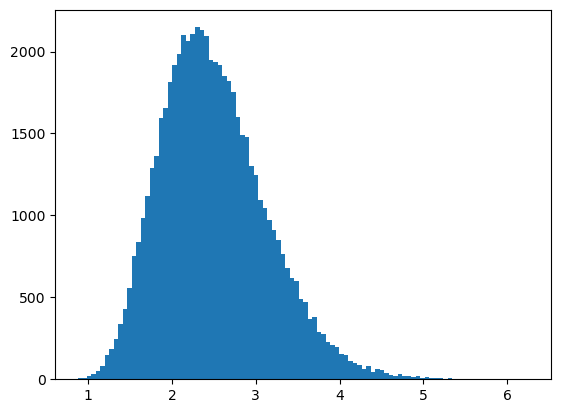

In [8]:
plt.hist(train_shape_df['thickness'].values, bins=100)

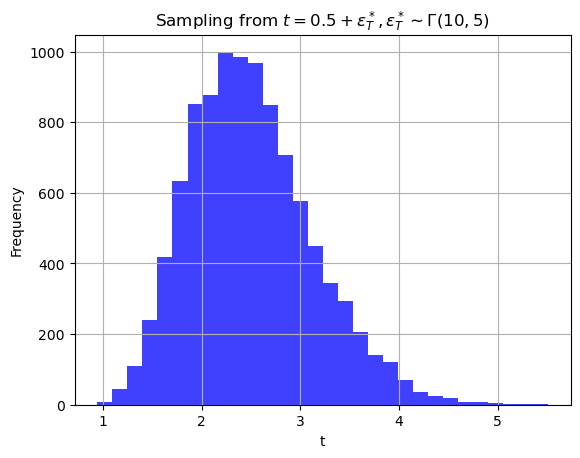

In [14]:
# 比較対象

import numpy as np
import matplotlib.pyplot as plt

# ガンマ分布からサンプリング
shape = 10  # 形状パラメータ
scale = 0.2   # スケールパラメータ Gammaオブジェクトでは第二引数が1 / scaleであることに注意せよ
epsilon_T_star = np.random.gamma(shape, scale, 10000)

# t の計算
thickness = 0.5 + epsilon_T_star

# 結果のヒストグラムをプロット
plt.hist(thickness, bins=30, alpha=0.75, color='blue')
plt.title(r'Sampling from $t = 0.5 + \epsilon_T^*, \epsilon_T^* \sim \Gamma(10, 5)$')
plt.xlabel('t')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


(array([  7.,  47.,  98., 178., 234., 313., 317., 483., 502., 568., 546.,
        591., 682., 661., 732., 683., 713., 744., 789., 762., 749., 748.,
        779., 834., 804., 822., 788., 858., 748., 777., 794., 797., 782.,
        776., 757., 771., 736., 793., 763., 744., 742., 753., 763., 715.,
        705., 697., 689., 654., 693., 668., 702., 661., 637., 644., 685.,
        644., 695., 639., 646., 621., 680., 662., 663., 635., 630., 639.,
        606., 615., 624., 588., 613., 574., 579., 549., 600., 521., 566.,
        560., 563., 555., 583., 542., 514., 545., 502., 547., 490., 471.,
        504., 521., 477., 472., 491., 427., 468., 411., 353., 302., 258.,
        177.]),
 array([ 66.601204  ,  68.48422366,  70.36724332,  72.25026298,
         74.13328264,  76.0163023 ,  77.89932196,  79.78234162,
         81.66536128,  83.54838094,  85.4314006 ,  87.31442026,
         89.19743992,  91.08045958,  92.96347924,  94.8464989 ,
         96.72951856,  98.61253822, 100.49555788, 102.37857754

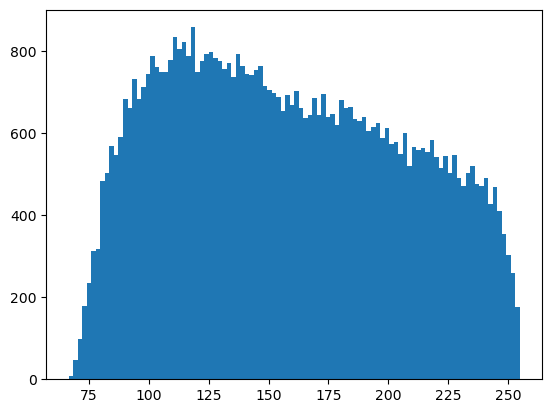

In [17]:
plt.hist(train_shape_df['intensity'].values, bins=100)